## Project 17: Link prediction 2

In [2]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from collections import Counter
import powerlaw

Dataset used: The Wikipedia vote network dataset. Available at: https://snap.stanford.edu/data/wiki-Vote.html

A directed graph is constructed from the dataset.

In [3]:
G = nx.read_edgelist(
    "Wiki-Vote.txt",
    comments="#",
    nodetype=int,
    create_using=nx.DiGraph()
)

print("Number of nodes :", nx.number_of_nodes(G))
print("Number of edges : ", nx.number_of_edges(G))

Number of nodes : 7115
Number of edges :  103689


A sample of 200 nodes is selected from the graph and visualized.

<Figure size 640x480 with 0 Axes>

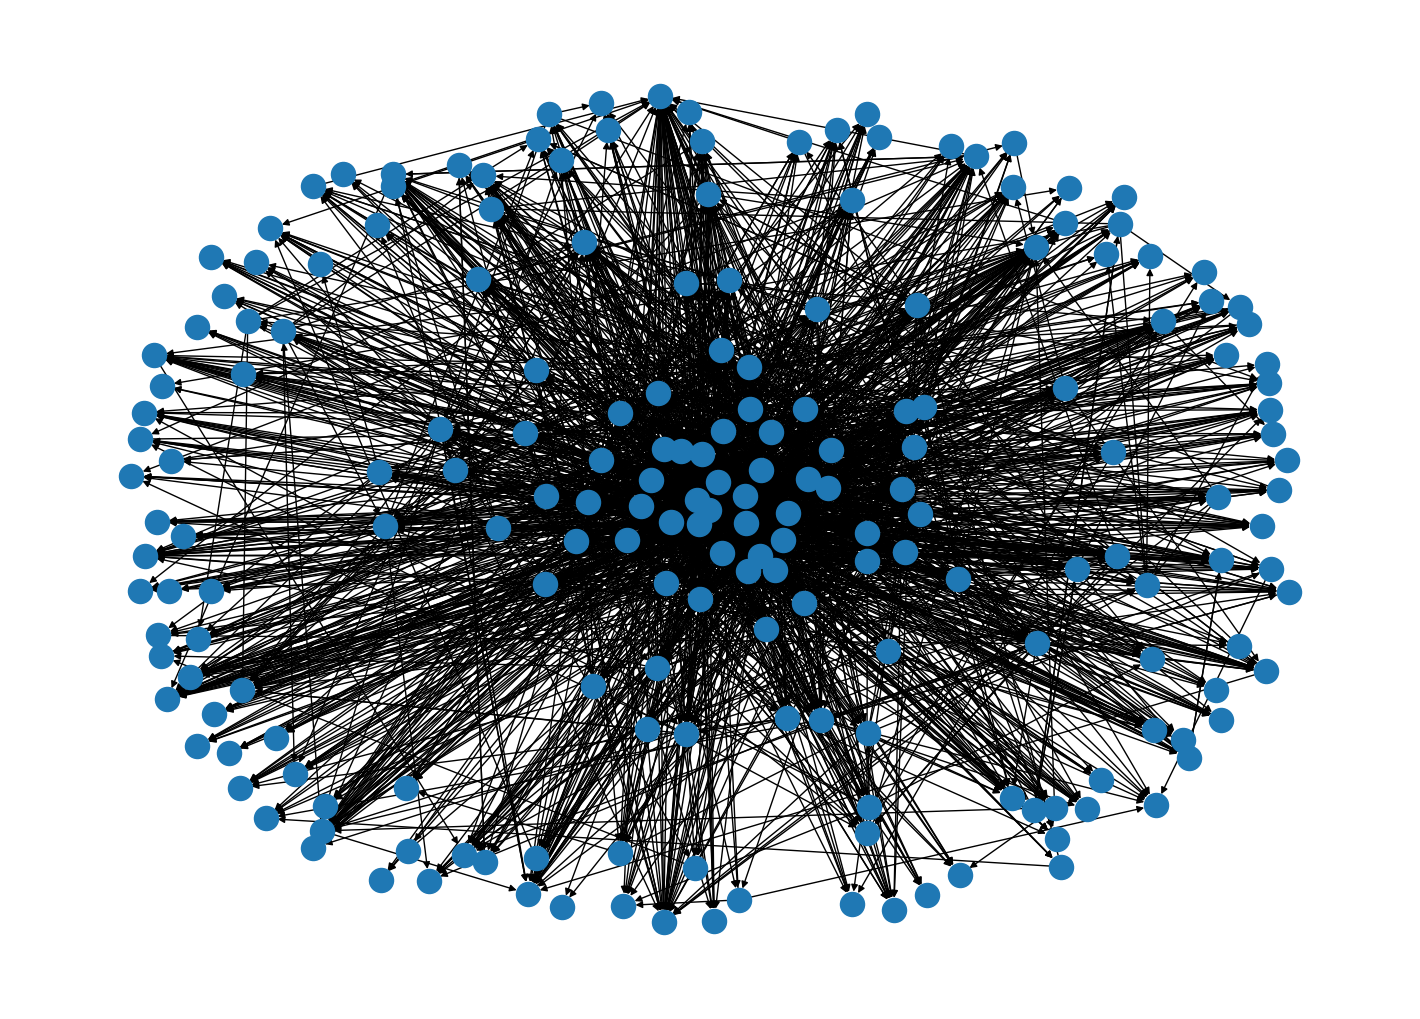

In [4]:
sample = G.subgraph(list(G.nodes())[:200])

plt.clf()
pos = nx.spring_layout(sample, seed=42, k=1)
plt.figure(figsize=(14, 10))
nx.draw(sample, pos, with_labels=False)
plt.show()


An adjacency matrix is generated from the sample and saved to an Excel file.
The full adjacency matrix was not constructed due to computational limitations.

In [33]:
adjacency_matrix = nx.adjacency_matrix(sample)

pandas_dataframe = pd.DataFrame(adjacency_matrix.toarray())
pandas_dataframe.to_excel("adjacency_matrix.xlsx")

A table is created displaying the mean and standard deviation of in-degree centrality, out-degree centrality, closeness centrality, and betweenness centrality.

In [14]:
in_degrees = nx.in_degree_centrality(G)
out_degrees = nx.out_degree_centrality(G)
closeness_centrality = nx.closeness_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G)

In [16]:
table = pd.DataFrame({
    "in_degree_centralities": list(in_degrees.values()),
    "out_degree_centralities": list(out_degrees.values()),
    "closeness_centralities": list(closeness_centrality.values()),
    "betweenness_centralities": list(betweenness_centrality.values())
    })

mean_and_std = pd.DataFrame({
    "mean": table.mean(),
    "standard deviation": table.std()
    })

print(mean_and_std)

                              mean  standard deviation
in_degree_centralities    0.002049            0.004460
out_degree_centralities   0.002049            0.005944
closeness_centralities    0.071484            0.103764
betweenness_centralities  0.000078            0.000461


In-degree and out-degree distribution plots

(array([5.90e+03, 4.64e+02, 2.55e+02, 1.25e+02, 9.90e+01, 6.60e+01,
        4.60e+01, 2.50e+01, 3.10e+01, 1.40e+01, 1.50e+01, 1.20e+01,
        1.30e+01, 9.00e+00, 3.00e+00, 8.00e+00, 4.00e+00, 8.00e+00,
        2.00e+00, 2.00e+00, 2.00e+00, 2.00e+00, 1.00e+00, 0.00e+00,
        0.00e+00, 1.00e+00, 1.00e+00, 0.00e+00, 0.00e+00, 0.00e+00,
        0.00e+00, 0.00e+00, 1.00e+00, 1.00e+00, 1.00e+00, 0.00e+00,
        0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00, 1.00e+00, 1.00e+00,
        0.00e+00, 1.00e+00, 0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00,
        0.00e+00, 1.00e+00]),
 array([  0.  ,  17.86,  35.72,  53.58,  71.44,  89.3 , 107.16, 125.02,
        142.88, 160.74, 178.6 , 196.46, 214.32, 232.18, 250.04, 267.9 ,
        285.76, 303.62, 321.48, 339.34, 357.2 , 375.06, 392.92, 410.78,
        428.64, 446.5 , 464.36, 482.22, 500.08, 517.94, 535.8 , 553.66,
        571.52, 589.38, 607.24, 625.1 , 642.96, 660.82, 678.68, 696.54,
        714.4 , 732.26, 750.12, 767.98, 785.84, 803.7 , 821.56, 83

<Figure size 640x480 with 0 Axes>

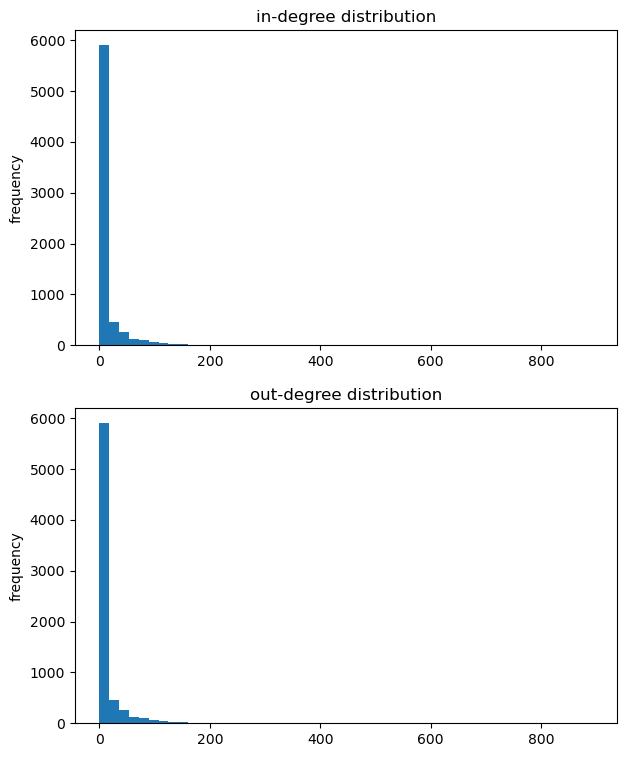

In [35]:
in_degrees = [d for n,d in G.in_degree()]
out_degrees = [d for n,d in G.out_degree()]

plt.clf()

plt.figure(figsize=(7, 9))

plt.subplot(2,1,1)
plt.title("in-degree distribution")
plt.ylabel("frequency")
plt.hist(out_degrees, bins=50)

plt.subplot(2,1,2)
plt.title("out-degree distribution")
plt.ylabel("frequency")
plt.hist(out_degrees, bins=50)

A script is implemented to generate and visualize a power-law distribution.

<Figure size 640x480 with 0 Axes>

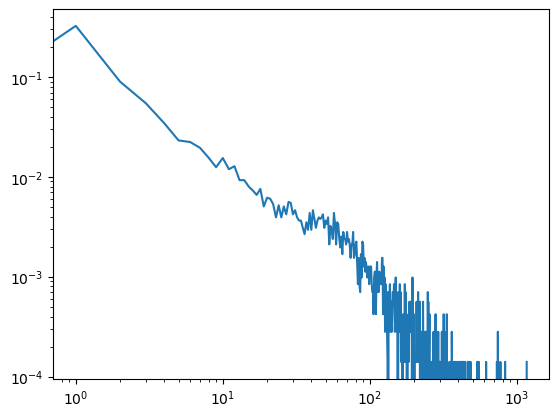

In [5]:

# compute the fraction of nodes (p_k) having degree k

histogram = nx.degree_histogram(G)

number_of_nodes = nx.number_of_nodes(G)

p_k = np.array(histogram) / number_of_nodes

# plot a log-log graph, where
#   x-axis: ln (k)
#   y-axis: ln (p_k)

k = np.arange(len(histogram))

plt.clf()
plt.figure()
plt.loglog(k, p_k)
plt.show()


A goodness-of-fit test is performed.
Source: https://github.com/powerlaw-devs/powerlaw/tree/master

alpha =  4.14869966168172
xmin =   248.0
R = -0.09253396147097259
p = 0.783987231790295


Calculating best minimal value for power law fit


<Figure size 640x480 with 0 Axes>

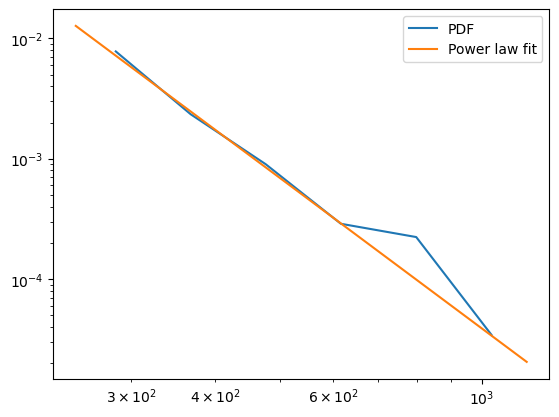

In [7]:
degrees = [d for n, d in G.degree()]

fit = powerlaw.Fit(degrees)

print("alpha = ", fit.power_law.alpha)
print("xmin =  ", fit.power_law.xmin)

R, p = fit.distribution_compare('power_law', 'lognormal')

print("R =", R)
print("p =", p)

plt.clf()

fig, ax = plt.subplots()

fit.plot_pdf(ax=ax, label='PDF')
fit.power_law.plot_pdf(ax=ax, label='Power law fit')

plt.legend()
plt.show()


Based on the obtained results, the degree distribution follows a power-law distribution at the 90% confidence level for degrees greater than 248 (p-value ~ 0.78 > 0.1).

The reciprocity of the network is calculated.

In [8]:
reciprocity = nx.overall_reciprocity(G)
print("reciprocity =", reciprocity)

reciprocity = 0.0564572905515532


Reciprocity is approximately 0.056 indicating that the vast majority of connections in the network are one-directional.

Identify the top 10 user IDs with the highest betweenness centrality scores and the top 10 with the highest closeness centrality values.

In [15]:
betweenness_centrality_sorted = sorted(betweenness_centrality.items(), key=lambda x: x[1], reverse=True)
top_10_betweenness = [node for node, value in betweenness_centrality_sorted[:10]]

degree_centrality = nx.degree_centrality(G)
degree_centrality_sorted = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)
top_10_centrality = [node for node, value in degree_centrality_sorted[:10]]

print(top_10_betweenness)
print(top_10_centrality)

[2565, 1549, 15, 72, 737, 1166, 5079, 2328, 2237, 28]
[2565, 1549, 766, 11, 1166, 457, 2688, 1374, 1151, 5524]


It is observed that the top 2 nodes are identical in both rankings: nodes 2565 and 1549.

Ego graphs are then created for these two nodes and visualized. The selected node is highlighted in red.

In [10]:
ego_top1 = nx.ego_graph(G, 2565)
ego_top2 = nx.ego_graph(G, 1549)

<Figure size 640x480 with 0 Axes>

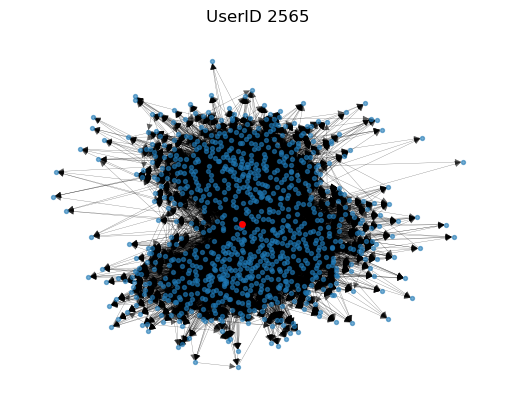

In [12]:
plt.clf()

pos = nx.spring_layout(ego_top1, seed=42, k=2)

plt.figure()
plt.title("UserID 2565")
nx.draw(ego_top1, pos, node_size=8, width=0.2, alpha=0.6)
nx.draw_networkx_nodes(ego_top1, pos, nodelist=[2565], node_color='red', node_size=15)
plt.show()


<Figure size 640x480 with 0 Axes>

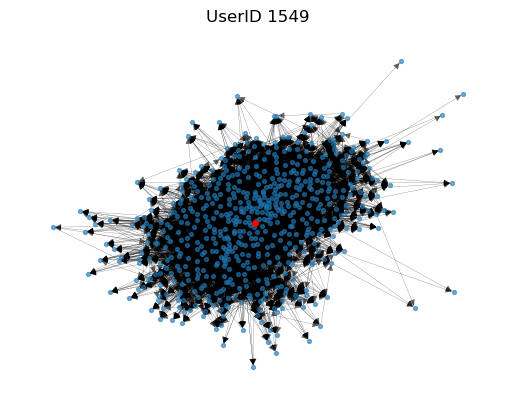

In [13]:
plt.clf()

pos = nx.spring_layout(ego_top2, seed=42, k=2)

plt.figure()
plt.title("UserID 1549")
nx.draw(ego_top2, pos, node_size=8, width=0.2, alpha=0.6)
nx.draw_networkx_nodes(ego_top1, pos, nodelist=[1549], node_color='red', node_size=15)
plt.show()

Identify k-core communities and k-plex communities in the original graph

In [ ]:
max_core = max(nx.core_number(G).values())
cores = {}

for k in range(1, max_core + 1):
    cores[k] = nx.k_core(G, k=k)

#TODO kesken!

In [ ]:
core_stats = []

for k, sub_graph in cores.items():
    undirected = sub_graph.to_undirected()
    size = sub_graph.number_of_nodes()
    diameter = None
    avg_shortest_path = None
    avg_clustering = None
    if nx.is_connected(undirected) and size <200:
        diameter = nx.diameter(undirected)
        avg_shortest_path = nx.average_shortest_path_length(undirected)
    avg_clustering = nx.average_clustering(undirected)
    core_stats.append({
        "k": k,
        "size": size,
        "diameter": diameter,
        "avg_shortest_path": avg_shortest_path,
        "avg_clustering": avg_clustering
    })

#TODO kesken!

In [ ]:
df_core = pd.DataFrame(core_stats, columns=[
    "k", "size", "diameter", "avg_path_length", "avg_clustering"
])

print (df_core)

#TODO kesken!